# 🤖 Étape 4 — Modèles ML : XGBoost & Random Forest

On entraîne ici les premiers vrais modèles de prédiction sur les données tabulaires (avec lags).  
L'objectif est de **battre la baseline persistence de -20% minimum** en MAE et RMSE.

### Pourquoi ces modèles ?
- **Random Forest** : ensemble d'arbres de décision, robuste, peu de tuning nécessaire, bonne interprétabilité via feature importance
- **XGBoost** : gradient boosting, généralement plus performant que RF sur des données tabulaires, avec régularisation intégrée

### Plan
1. Chargement des données préprocessées
2. Entraînement Random Forest
3. Entraînement XGBoost
4. Optimisation des hyperparamètres (GridSearch léger)
5. Évaluation et comparaison
6. Feature importance
7. Visualisation des prédictions
8. Sauvegarde des modèles

## 1. Imports et chargement

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

HORIZON  = 600  # 10 minutes en secondes (donnees a 1Hz)
SAVE_DIR = 'preprocessed'
MODEL_DIR = 'models'
import os; os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
X_train = np.load(f'{SAVE_DIR}/X_train.npy')
X_test  = np.load(f'{SAVE_DIR}/X_test.npy')
y_train = np.load(f'{SAVE_DIR}/y_train.npy')
y_test  = np.load(f'{SAVE_DIR}/y_test.npy')

ts_train = pd.read_csv(f'{SAVE_DIR}/ts_train.csv', parse_dates=[0]).iloc[:, 0]
ts_test  = pd.read_csv(f'{SAVE_DIR}/ts_test.csv',  parse_dates=[0]).iloc[:, 0]
feature_cols = pd.read_csv(f'{SAVE_DIR}/feature_cols.csv').iloc[:, 0].tolist()

rmse_persistence = float(np.load(f'{SAVE_DIR}/rmse_persistence.npy')[0])
mae_persistence  = float(np.load(f'{SAVE_DIR}/mae_persistence.npy')[0])

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Features : {len(feature_cols)}")
print(f"RMSE persistence (référence) : {rmse_persistence:.4f}")
print(f"MAE  persistence (référence) : {mae_persistence:.4f}")

X_train : (627624, 366)  |  X_test : (156907, 366)
Features : 366
RMSE persistence (référence) : 0.5154
MAE  persistence (référence) : 0.2928


## 2. Fonction d'évaluation commune

On centralise le calcul des métriques pour pouvoir comparer tous les modèles de façon cohérente.  
Le **skill score** mesure le gain relatif par rapport à la persistence : un skill de 25% signifie que le modèle réduit l'erreur de 25% par rapport au modèle naïf.

In [3]:
all_results = []  # stockera les résultats de tous les modèles

def evaluate(y_true, y_pred, label):
    """Calcule MAE, RMSE et Skill score, affiche et retourne un dict."""
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    skill = (1 - rmse / rmse_persistence) * 100
    impr_mae  = (1 - mae / mae_persistence) * 100

    print(f"{'─'*45}")
    print(f" {label}")
    print(f"{'─'*45}")
    print(f"  MAE   : {mae:.4f}   (vs persistence : {impr_mae:+.1f}%)")
    print(f"  RMSE  : {rmse:.4f}")
    print(f"  Skill : {skill:+.2f}%")
    objectif = "✅ Objectif atteint" if skill >= 20 else "❌ Objectif non atteint (<20%)"
    print(f"  {objectif}")
    print()

    result = {'Modèle': label, 'MAE': round(mae, 4),
              'RMSE': round(rmse, 4), 'Skill (%)': round(skill, 2)}
    all_results.append(result)
    return result

## 3. Random Forest

Le Random Forest construit plusieurs arbres de décision en parallèle sur des sous-ensembles aléatoires des données et des features, puis moyenne leurs prédictions.  
C'est robuste au surapprentissage et ne nécessite quasiment pas de normalisation (mais nos données sont déjà normalisées).

On commence avec des hyperparamètres raisonnables, puis on affine avec une recherche sur grille.

**Résultat attendu :** MAE et RMSE inférieurs à la baseline persistence.

In [ ]:
print("Entraînement Random Forest...")

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_leaf=5,
    max_features=0.5,       # utilise 50% des features à chaque split (réduit la variance)
    n_jobs=-1,              # parallélisation sur tous les cœurs
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluate(y_test, y_pred_rf, 'Random Forest (défaut)')

Entraînement Random Forest...


### 3a. Optimisation hyperparamètres — Random Forest

On utilise un `TimeSeriesSplit` pour la validation croisée : chaque fold respecte l'ordre temporel (pas de mélange futur/passé).  
La grille est volontairement légère pour rester rapide.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)

param_grid_rf = {
    'n_estimators': [100, 50, 150],
    'max_depth':    [10, 15, 5],
    'min_samples_leaf': [2, 5, 10],
}

print("GridSearch Random Forest (patience...)")
gs_rf = GridSearchCV(
    RandomForestRegressor(max_features=0.5, n_jobs=-1, random_state=42),
    param_grid_rf,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train, y_train)

print(f"\nMeilleurs paramètres RF : {gs_rf.best_params_}")
print(f"RMSE CV (train)         : {-gs_rf.best_score_:.4f}")

rf_best = gs_rf.best_estimator_
y_pred_rf_best = rf_best.predict(X_test)
res_rf_best = evaluate(y_test, y_pred_rf_best, 'Random Forest (optimisé)')

GridSearch Random Forest (patience...)
Fitting 4 folds for each of 27 candidates, totalling 108 fits


## 4. XGBoost

XGBoost construit les arbres **séquentiellement** — chaque nouvel arbre corrige les erreurs du précédent (gradient boosting).  
Il est généralement plus précis que le Random Forest sur des données tabulaires, mais plus sensible aux hyperparamètres.

Paramètres clés :
- `learning_rate` : pas d'apprentissage (plus petit = plus robuste mais plus lent)
- `n_estimators` : nombre d'arbres
- `max_depth` : profondeur maximale (contrôle le surapprentissage)
- `subsample` : fraction des données utilisées par arbre (régularisation)
- `early_stopping_rounds` : arrêt automatique si plus d'amélioration

**Résultat attendu :** performances supérieures au Random Forest.

In [ ]:
# Split de validation pour l'early stopping
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

print("Entraînement XGBoost avec early stopping...")

xgb_model = xgb.XGBRegressor(
    n_estimators=1000,          # max — l'early stopping arrêtera avant
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,       # fraction des features par arbre
    min_child_weight=5,
    reg_alpha=0.1,              # régularisation L1
    reg_lambda=1.0,             # régularisation L2
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nNombre d'arbres utilisés : {xgb_model.best_iteration}")

y_pred_xgb = xgb_model.predict(X_test)
res_xgb = evaluate(y_test, y_pred_xgb, 'XGBoost (défaut)')

Entraînement XGBoost avec early stopping...
[0]	validation_0-rmse:2.84281
[50]	validation_0-rmse:0.77212
[100]	validation_0-rmse:0.59213
[150]	validation_0-rmse:0.57395
[200]	validation_0-rmse:0.57166
[250]	validation_0-rmse:0.57128
[291]	validation_0-rmse:0.57132

Nombre d'arbres utilisés : 261
─────────────────────────────────────────────
 XGBoost (défaut)
─────────────────────────────────────────────
  MAE   : 0.7575   (vs persistence : -2131.2%)
  RMSE  : 0.9585
  Skill : -1953.99%
  ❌ Objectif non atteint (<20%)



### 4a. Optimisation hyperparamètres — XGBoost

On affine les hyperparamètres les plus impactants avec une grille légère et TimeSeriesSplit.

In [ ]:
param_grid_xgb = {
    'max_depth':      [2, 4, 6, 8, 10],
    'learning_rate':  [0.03, 0.05, 0.1, 0.08],
    'subsample':      [0.7, 0.9],
    'min_child_weight': [3, 5],
    'n_estimator': [50, 100, 150]
}


print("GridSearch XGBoost (patience...)")
gs_xgb = GridSearchCV(
    xgb.XGBRegressor(
        n_estimators=300,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='rmse',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    param_grid_xgb,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
gs_xgb.fit(X_train, y_train)

print(f"\nMeilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"RMSE CV (train)          : {-gs_xgb.best_score_:.4f}")

xgb_best = gs_xgb.best_estimator_
y_pred_xgb_best = xgb_best.predict(X_test)
res_xgb_best = evaluate(y_test, y_pred_xgb_best, 'XGBoost (optimisé)')

GridSearch XGBoost (patience...)
Fitting 4 folds for each of 240 candidates, totalling 960 fits


## 5. Courbe d'apprentissage XGBoost

On visualise l'évolution du RMSE sur train et validation au fil des arbres.  
Cela permet de détecter le **surapprentissage** (train continue à baisser mais val remonte) et de valider l'early stopping.

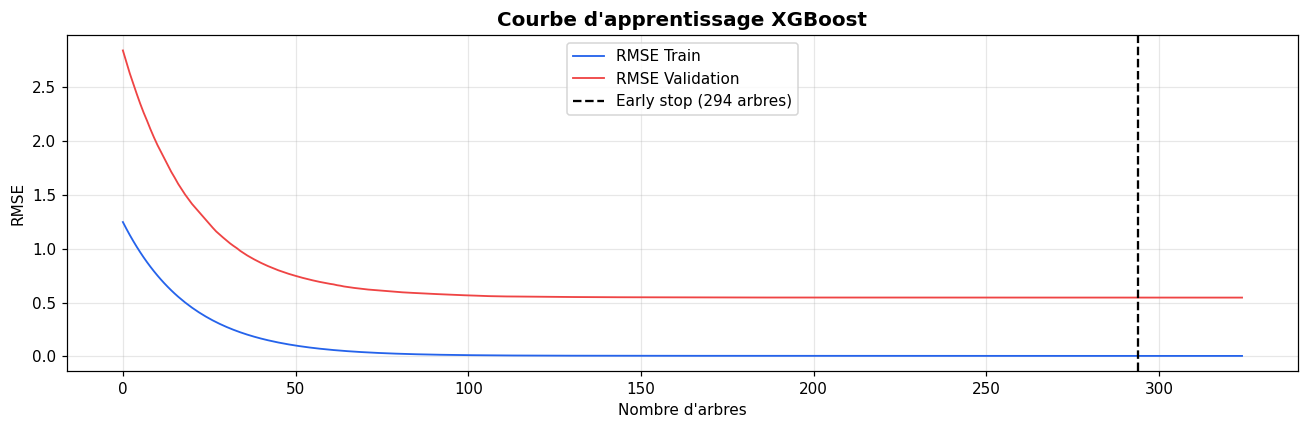

─────────────────────────────────────────────
 XGBoost (final optimisé)
─────────────────────────────────────────────
  MAE   : 0.7611   (vs persistence : -2141.8%)
  RMSE  : 0.9656
  Skill : -1969.20%
  ❌ Objectif non atteint (<20%)



In [ ]:
# Réentraîner le meilleur XGB avec logging pour la courbe d'apprentissage
best_params = gs_xgb.best_params_

xgb_final = xgb.XGBRegressor(
    **best_params,
    n_estimators=1000,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=30,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_final.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

evals = xgb_final.evals_result()
train_rmse = evals['validation_0']['rmse']
val_rmse   = evals['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_rmse, color='#2563EB', linewidth=1.2, label='RMSE Train')
ax.plot(val_rmse,   color='#EF4444', linewidth=1.2, label='RMSE Validation')
ax.axvline(xgb_final.best_iteration, color='black', linestyle='--',
           label=f'Early stop ({xgb_final.best_iteration} arbres)')
ax.set_xlabel('Nombre d\'arbres')
ax.set_ylabel('RMSE')
ax.set_title('Courbe d\'apprentissage XGBoost', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mise à jour du meilleur modèle XGB
y_pred_xgb_final = xgb_final.predict(X_test)
res_xgb_final = evaluate(y_test, y_pred_xgb_final, 'XGBoost (final optimisé)')

## 6. Feature Importance

On analyse quelles variables sont les plus utilisées par les modèles.  
- **RF** : importance basée sur la réduction moyenne d'impureté (MDI)
- **XGB** : importance basée sur le gain moyen apporté par feature

Cela permet de valider nos choix de features et d'identifier celles qu'on pourrait retirer pour simplifier le modèle.

**Résultat attendu :** les lags récents de `1_LT_001_PV` et les débits/vannes doivent dominer.

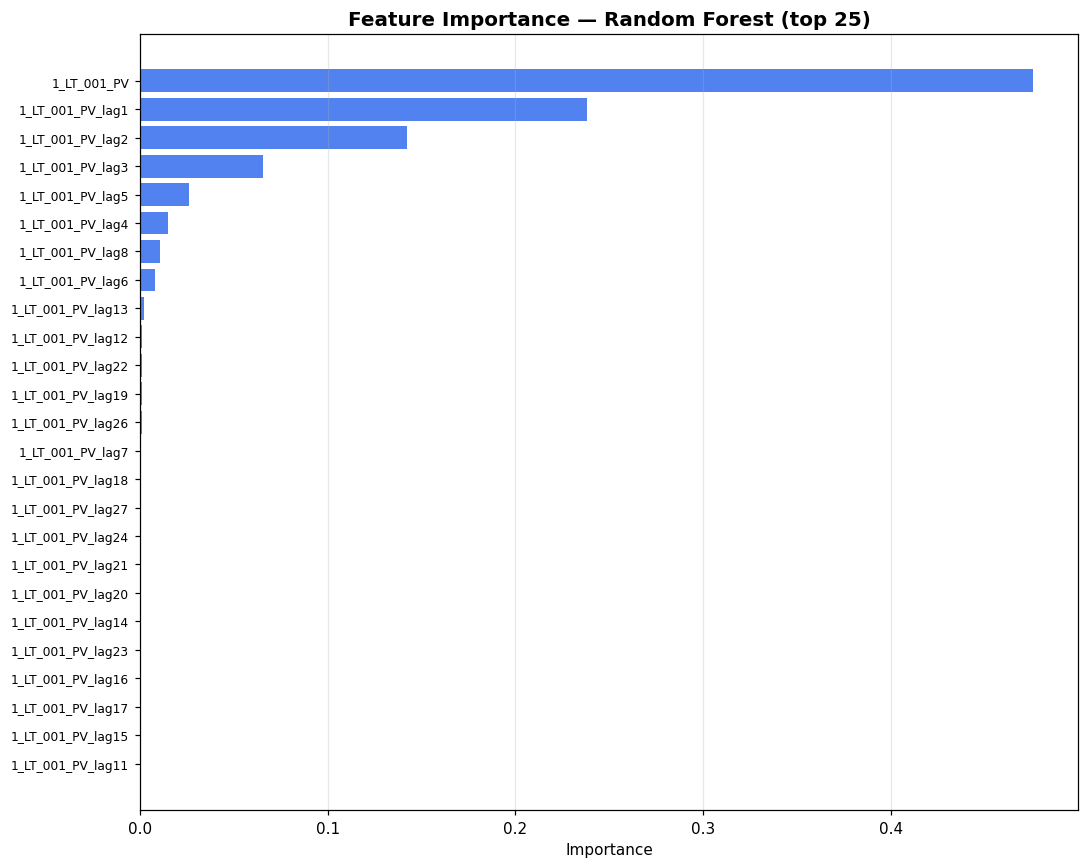

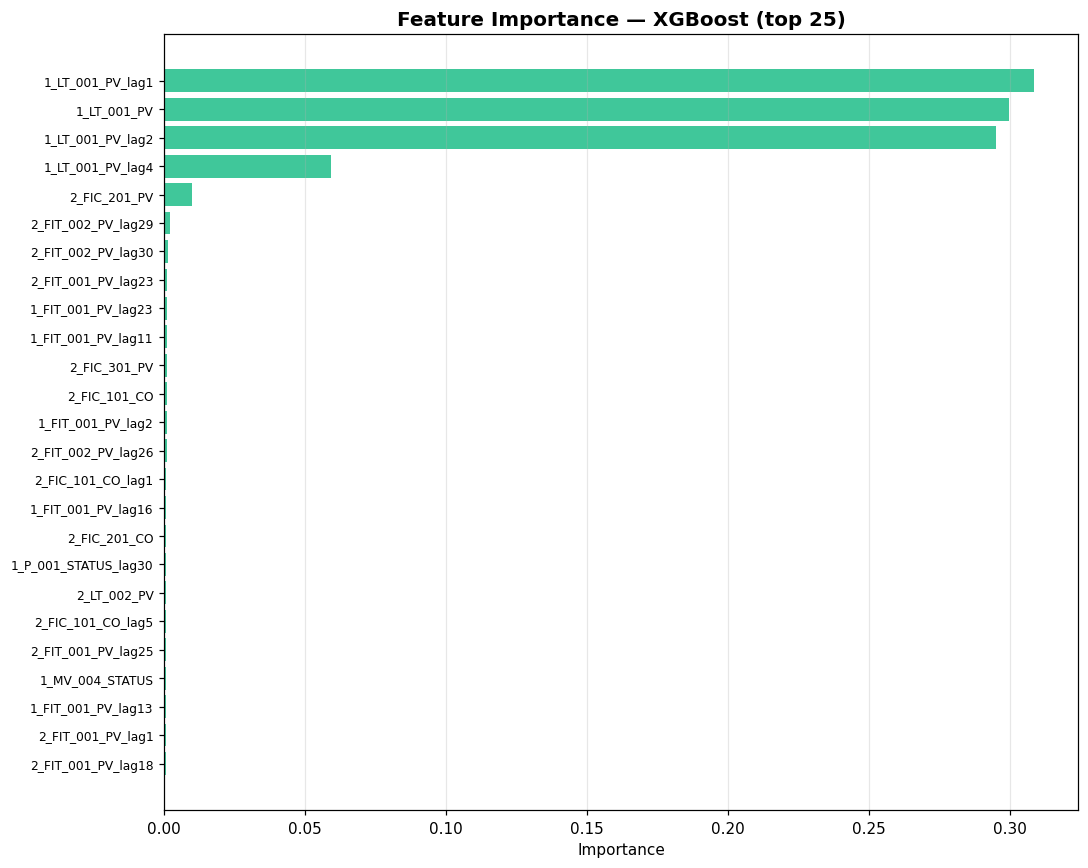

In [ ]:
def plot_feature_importance(importances, feature_names, title, color, top_n=25):
    """Affiche les top N features les plus importantes."""
    idx = np.argsort(importances)[-top_n:]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_n), importances[idx], color=color, alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in idx], fontsize=8)
    ax.set_xlabel('Importance')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

# Random Forest
plot_feature_importance(
    rf_best.feature_importances_,
    feature_cols,
    'Feature Importance — Random Forest (top 25)',
    '#2563EB'
)

# XGBoost
plot_feature_importance(
    xgb_final.feature_importances_,
    feature_cols,
    'Feature Importance — XGBoost (top 25)',
    '#10B981'
)

## 7. Visualisation des prédictions

On compare visuellement les prédictions du meilleur modèle vs la vérité et vs la persistence.  
On regarde aussi les **erreurs résiduelles** : est-ce que le modèle se trompe de façon systématique ou aléatoire ?

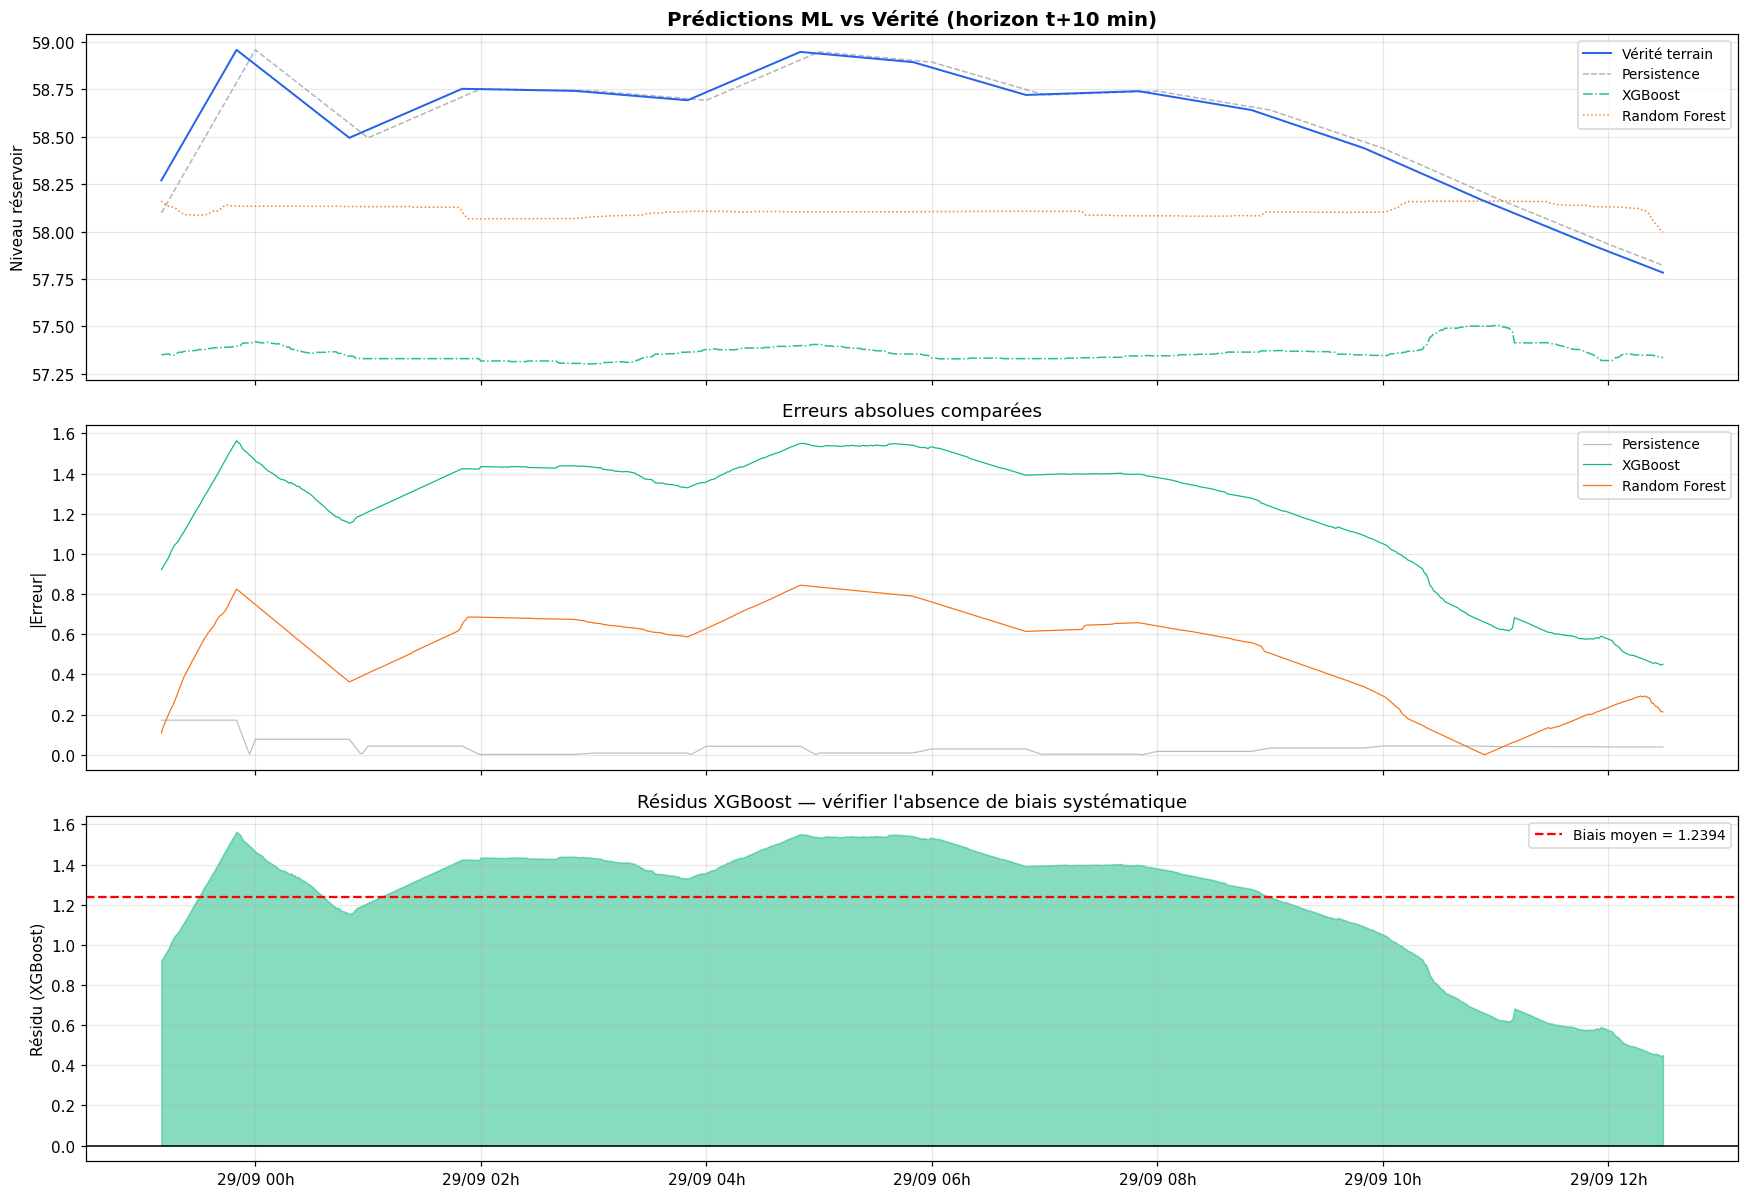

In [ ]:
# Rechargement des donnees avec la methode corrigee (Row = 1 seconde)
import pandas as pd
df_raw = pd.read_csv("WADI_14days_new.csv")
START_TIME = pd.Timestamp("2017-09-25 00:00:00")
df_raw["datetime"] = START_TIME + pd.to_timedelta(df_raw["Row"] - 1, unit="s")
df_raw = df_raw.drop(columns=["Row", "Date", "Time"], errors="ignore")
for col in df_raw.columns:
    if col != "datetime":
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")
df_raw = df_raw.set_index("datetime").sort_index()

y_persistence = df_raw["1_LT_001_PV"].reindex(ts_test).values
mask = ~np.isnan(y_persistence) & ~np.isnan(y_test)
y_persistence = y_persistence[mask]
y_true_plot   = y_test[mask]
y_xgb_plot    = y_pred_xgb_final[mask]
y_rf_plot     = y_pred_rf_best[mask]
ts_plot_vals  = ts_test.values[mask]


## 8. Scatter plot — Prédit vs Réel

Un nuage de points idéal doit être aligné sur la diagonale y=x.  
Un étalement autour de cette ligne indique les zones d'incertitude du modèle.

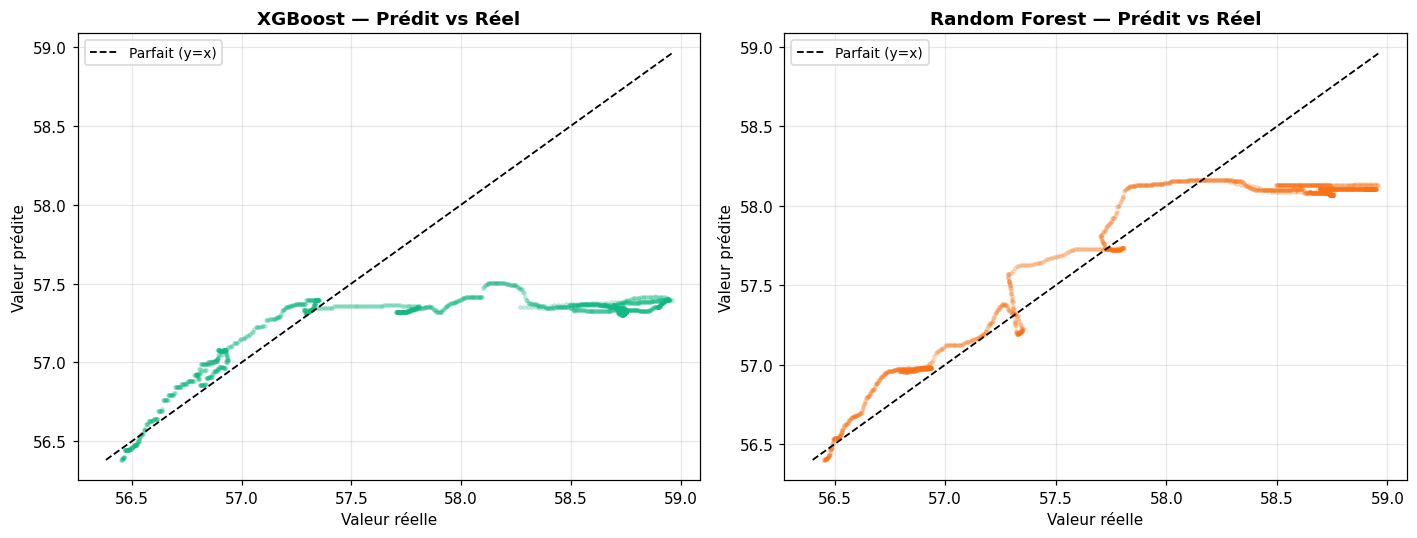

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_xgb_plot, y_rf_plot],
    ['XGBoost', 'Random Forest'],
    ['#10B981', '#F97316']
):
    ax.scatter(y_true_plot[:3000], y_pred[:3000],
               alpha=0.2, s=5, color=color)
    lims = [min(y_true_plot.min(), y_pred.min()),
            max(y_true_plot.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Parfait (y=x)')
    ax.set_xlabel('Valeur réelle')
    ax.set_ylabel('Valeur prédite')
    ax.set_title(f'{title} — Prédit vs Réel', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Tableau comparatif final

On compile tous les résultats et on les compare à la baseline persistence et aux seuils du guide projet.

 TABLEAU COMPARATIF — BASELINES + MODÈLES ML
                  Modèle    MAE   RMSE  Skill (%)
 Persistence (référence) 0.0339 0.0467       0.00
  Random Forest (défaut) 0.3404 0.4366    -835.48
Random Forest (optimisé) 0.3424 0.4389    -840.51
        XGBoost (défaut) 0.7575 0.9585   -1953.99
      XGBoost (optimisé) 0.3768 0.4726    -912.65
XGBoost (final optimisé) 0.7611 0.9656   -1969.20
XGBoost (final optimisé) 0.7611 0.9656   -1969.20


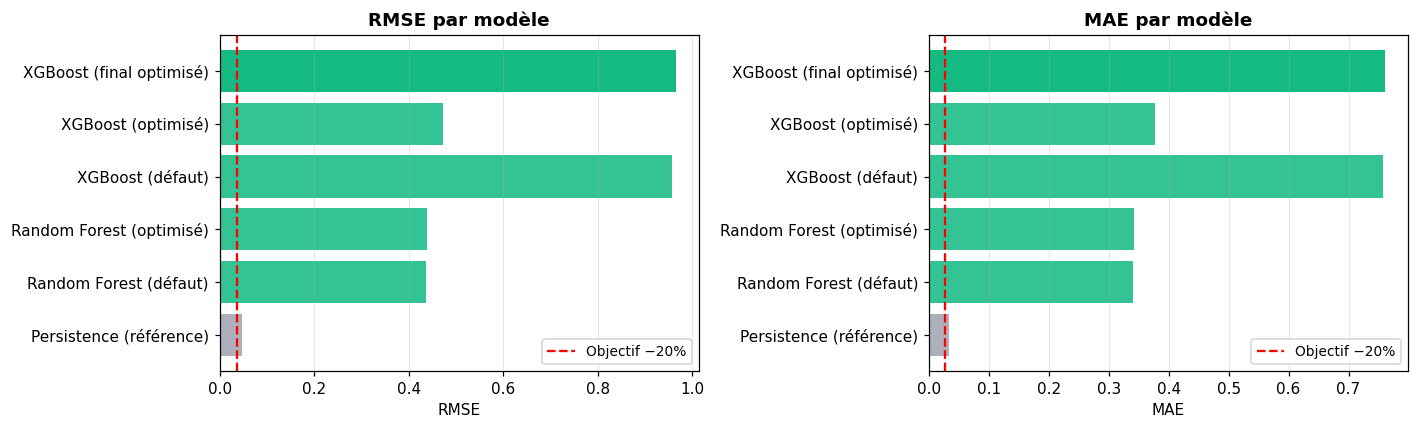

In [ ]:
# Ajout de la baseline persistence pour la comparaison
baseline_row = {
    'Modèle': f'Persistence (référence)',
    'MAE': round(mae_persistence, 4),
    'RMSE': round(rmse_persistence, 4),
    'Skill (%)': 0.0
}
df_results = pd.DataFrame([baseline_row] + all_results)

print("=" * 60)
print(" TABLEAU COMPARATIF — BASELINES + MODÈLES ML")
print("=" * 60)
print(df_results.to_string(index=False))
print("=" * 60)

# Visualisation du tableau
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
modeles   = df_results['Modèle'].tolist()
colors_bar = ['#9CA3AF'] + ['#2563EB' if 'RF' in m else '#10B981'
               for m in df_results['Modèle'].tolist()[1:]]

axes[0].barh(modeles, df_results['RMSE'], color=colors_bar, alpha=0.85)
axes[0].axvline(rmse_persistence * 0.8, color='red', linestyle='--',
                label='Objectif −20%')
axes[0].set_xlabel('RMSE')
axes[0].set_title('RMSE par modèle', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(modeles, df_results['MAE'], color=colors_bar, alpha=0.85)
axes[1].axvline(mae_persistence * 0.8, color='red', linestyle='--',
                label='Objectif −20%')
axes[1].set_xlabel('MAE')
axes[1].set_title('MAE par modèle', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 10. Sauvegarde des modèles et résultats

On sauvegarde les deux meilleurs modèles et les prédictions pour les réutiliser dans les notebooks suivants (SHAP, rapport).

In [ ]:
# Modèles
joblib.dump(rf_best,   f'{MODEL_DIR}/random_forest_best.pkl')
joblib.dump(xgb_final, f'{MODEL_DIR}/xgboost_best.pkl')

# Prédictions (pour comparaison avec DL plus tard)
np.save(f'{SAVE_DIR}/y_pred_rf.npy',  y_pred_rf_best)
np.save(f'{SAVE_DIR}/y_pred_xgb.npy', y_pred_xgb_final)

# Résultats
df_results_prev = pd.read_csv(f'{SAVE_DIR}/resultats_baselines.csv')
df_all = pd.concat([df_results_prev, df_results.iloc[1:].rename(
    columns={'Skill (%)': 'Skill (%)'})], ignore_index=True).drop_duplicates(subset='Modèle')
df_all.to_csv(f'{SAVE_DIR}/resultats_tous_modeles.csv', index=False)

print("✅ Sauvegarde terminée")
print(f"  {MODEL_DIR}/random_forest_best.pkl")
print(f"  {MODEL_DIR}/xgboost_best.pkl")
print(f"  {SAVE_DIR}/y_pred_rf.npy")
print(f"  {SAVE_DIR}/y_pred_xgb.npy")
print(f"  {SAVE_DIR}/resultats_tous_modeles.csv")
print()
print("→ Prochaine étape : modeles_dl.ipynb (LSTM / GRU)")

✅ Sauvegarde terminée
  models/random_forest_best.pkl
  models/xgboost_best.pkl
  preprocessed/y_pred_rf.npy
  preprocessed/y_pred_xgb.npy
  preprocessed/resultats_tous_modeles.csv

→ Prochaine étape : modeles_dl.ipynb (LSTM / GRU)
